<a href="https://colab.research.google.com/github/madan-genai/natural-language-processing-ml-projects/blob/main/Image_Classifier_using_keras_and_Tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

load the MNIST dataset

In [ ]:
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

Preprocessing: Normalize the pixel values to be between o and 1

In [ ]:
train_images = train_images/255.0
test_images = test_images/255.0

Reshape the images to (28, 28, 1) as they are grayscale

In [ ]:
train_images=train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images=test_images.reshape((test_images.shape[0], 28, 28, 1))

Convert the labels to one hot encoded format

In [ ]:
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

Build the CNN model

In [ ]:
model = models.Sequential()

First convolution layer

In [ ]:
model.add(layers.Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Second convolution layer

In [ ]:
model.add(layers.Conv2D(64, (3,3), activation="relu"))
model.add(layers.MaxPooling2D(2,2))

Third convolution layer

In [ ]:
model.add(layers.Conv2D(64, (3,3),activation="relu"))

Flatten the 3D output to 1D and add a dense layer

In [ ]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation="relu"))

Output Layer with 10 neuron(for 10 digit classes

In [ ]:
model.add(layers.Dense(10, activation="softmax"))

Compile the model

In [ ]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

Train the model

In [ ]:
model.fit(train_images, train_labels, epochs=5, batch_size=64, validation_data=(test_images, test_labels))

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 105s 110ms/step - accuracy: 0.8955 - loss: 0.3585 - val_accuracy: 0.9864 - val_loss: 0.0431
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 143s 111ms/step - accuracy: 0.9865 - loss: 0.0446 - val_accuracy: 0.9892 - val_loss: 0.0342
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 107s 114ms/step - accuracy: 0.9909 - loss: 0.0296 - val_accuracy: 0.9904 - val_loss: 0.0309
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 141s 114ms/step - accuracy: 0.9927 - loss: 0.0218 - val_accuracy: 0.9911 - val_loss: 0.0270
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 138s 109ms/step - accuracy: 0.9949 - loss: 0.0166 - val_accuracy: 0.9922 - val_loss: 0.0245


Evaluate the model on test data

In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9894 - loss: 0.0319
Test accuracy: 99.22%


Make predictions on test images

In [ ]:
predictions=model.predict(test_images)
print(f"Prediction for first test image: {np.argmax(predictions[0])}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step
Prediction for first test image: 7


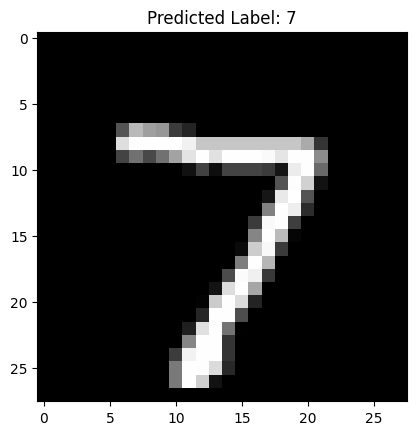

In [ ]:
plt.imshow(test_images[0].reshape(28,28), cmap="gray")
plt.title(f"Predicted Label: {predictions[0].argmax()}")
plt.show()